In [1]:
import time
from collections import defaultdict
from typing import Callable, List, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as sps
import seaborn as sns
import torch
from catboost import CatBoostRegressor
from pylab import rcParams
from sktime.split import ExpandingWindowSplitter
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
)
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.preprocessing import MinMaxScaler
from statsforecast import models as sf_models
from statsforecast.models import (
    SimpleExponentialSmoothing,
    SimpleExponentialSmoothingOptimized,
)
from torch import nn
from torch.utils.data import DataLoader, Dataset, random_split
from tqdm import tqdm
from tqdm.auto import tqdm as auto_tqdm

from IPython.display import HTML, clear_output, display
import plotly.graph_objects as go
import statsmodels
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

from statsmodels.tsa.holtwinters import ExponentialSmoothing, Holt, SimpleExpSmoothing
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import tsfresh
from tsfresh import extract_features, select_features
from tsfresh.feature_extraction import settings
from tsfresh.utilities.dataframe_functions import impute, roll_time_series

# Visualization setup
sns.set(font_scale=1.3, palette="Set2")
rcParams['figure.figsize'] = 15, 7
%matplotlib inline

## Обработка

In [2]:
chemicals_raw = pd.read_excel(
    "/home/danilach/mipt-stats/SberTs/Цены удобрения и химия_до 06.2025-1.xlsx"
)

In [3]:
chemicals_raw = pd.read_excel(
    "/home/danilach/mipt-stats/SberTs/Цены удобрения и химия_до 06.2025-1.xlsx"
)

chemicals_raw = chemicals_raw.T
chemicals_raw.set_index(1)
chemicals_raw.columns = chemicals_raw.iloc[0]
chemicals_raw = chemicals_raw[2:]
chemicals_raw.index = pd.to_datetime(chemicals_raw.index)
chemicals_raw.index.name = "Date"
chemicals_raw.columns.name = "chemical"

In [4]:
products = chemicals_raw.dropna(axis="columns")
products.head()

chemical,Карбамид (FOB Южный),"Моноаммонийфосфат, MAP (FOB Балтика)",Апатитовый концетрат (FOB Morocco),Аммиак (FOB Черное море),Аммиачная селитра (FOB Черное море),Хлорид калия (CFR Ю-В Азия),Капролактам импортный контракт (Тайвань и Ю. Корея) CFR Азия,Метанол,"Бензол, CFR Япония","Этилен, CFR Китай"
Date,,,,,,,,,,
2016-01-01,209.875,366.25,120.0,266.666667,199.375,278.75,1153.0,185.4,556.0,987.5
2016-02-01,207.125,332.5,117.5,260.5,182.125,272.5,1163.0,150.0,546.25,927.5
2016-03-01,199.875,345.0,117.5,267.5,180.3,267.5,1290.0,164.75,625.0,1173.75
2016-04-01,203.875,346.25,115.0,271.0,172.0,267.5,1355.0,179.9,642.0,1192.5
2016-05-01,200.5,341.5,107.5,279.25,154.75,251.875,1278.0,201.25,631.25,1160.0


In [5]:
macro = pd.read_excel("/home/danilach/mipt-stats/SberTs/global_macro.xlsx", index_col="Date")   
macro.head()

,"Инфляция - Рост индекса цен производителей (RUB, eop PPI),","Инфляция - Рост индекса потребительских цен в США, в долларах США (USD, eop CPI),","Инфляция - Рост индекса потребительских цен в США, в долларах США (USD, eop CPI), .1","Инфляция - Рост индекса цен производителей в США, в долларах США (USD, eop PPI),","Ключевая ставка, годовых","Инфляция, г/г"
Date,,,,,,
"08,2025",NaN,0.2,0.2,0.009,NaN,NaN
"07,2025",-0.013,0.3,0.3,0.000,18.0,8.79
"06,2025",-0.013,0.1,0.1,0.001,20.0,9.40
"05,2025",-0.014,0.2,0.2,-0.005,21.0,9.88
"04,2025",-0.015,-0.1,-0.1,-0.004,21.0,10.23


In [6]:
print(len(macro))
print(len(products))
print(products.index[0])
print(products.index[-1])
print(macro.index[0])
print(macro.index[-1])

140
114
2016-01-01 00:00:00
2025-06-01 00:00:00
08,2025
01,2014


In [7]:
macro = macro[::-1]
macro = macro[24:-2]
print(macro.index[0])
print(macro.index[-1])
print(products.index[0])
print(products.index[-1])

01,2016
06,2025
2016-01-01 00:00:00
2025-06-01 00:00:00


In [8]:
df = products.copy()
df[macro.columns] = macro.values

df.head()

chemical,Карбамид (FOB Южный),"Моноаммонийфосфат, MAP (FOB Балтика)",Апатитовый концетрат (FOB Morocco),Аммиак (FOB Черное море),Аммиачная селитра (FOB Черное море),Хлорид калия (CFR Ю-В Азия),Капролактам импортный контракт (Тайвань и Ю. Корея) CFR Азия,Метанол,"Бензол, CFR Япония","Этилен, CFR Китай","Инфляция - Рост индекса цен производителей (RUB, eop PPI),","Инфляция - Рост индекса потребительских цен в США, в долларах США (USD, eop CPI),","Инфляция - Рост индекса потребительских цен в США, в долларах США (USD, eop CPI), .1","Инфляция - Рост индекса цен производителей в США, в долларах США (USD, eop PPI),","Ключевая ставка, годовых","Инфляция, г/г"
Date,,,,,,,,,,,,,,,,
2016-01-01,209.875,366.25,120.0,266.666667,199.375,278.75,1153.0,185.4,556.0,987.5,-0.022,-0.1,-0.1,-0.002,11.0,9.8
2016-02-01,207.125,332.5,117.5,260.5,182.125,272.5,1163.0,150.0,546.25,927.5,-0.012,0.0,0.0,0.001,11.0,8.1
2016-03-01,199.875,345.0,117.5,267.5,180.3,267.5,1290.0,164.75,625.0,1173.75,-0.015,-0.2,-0.2,-0.002,11.0,7.3
2016-04-01,203.875,346.25,115.0,271.0,172.0,267.5,1355.0,179.9,642.0,1192.5,0.031,0.1,0.1,-0.001,11.0,7.3
2016-05-01,200.5,341.5,107.5,279.25,154.75,251.875,1278.0,201.25,631.25,1160.0,0.026,0.4,0.4,0.002,11.0,7.3


In [9]:
scaler = StandardScaler()

df_normalized = pd.DataFrame(
    scaler.fit_transform(df), columns=df.columns, index=df.index
)

means = scaler.mean_
stds = scaler.scale_

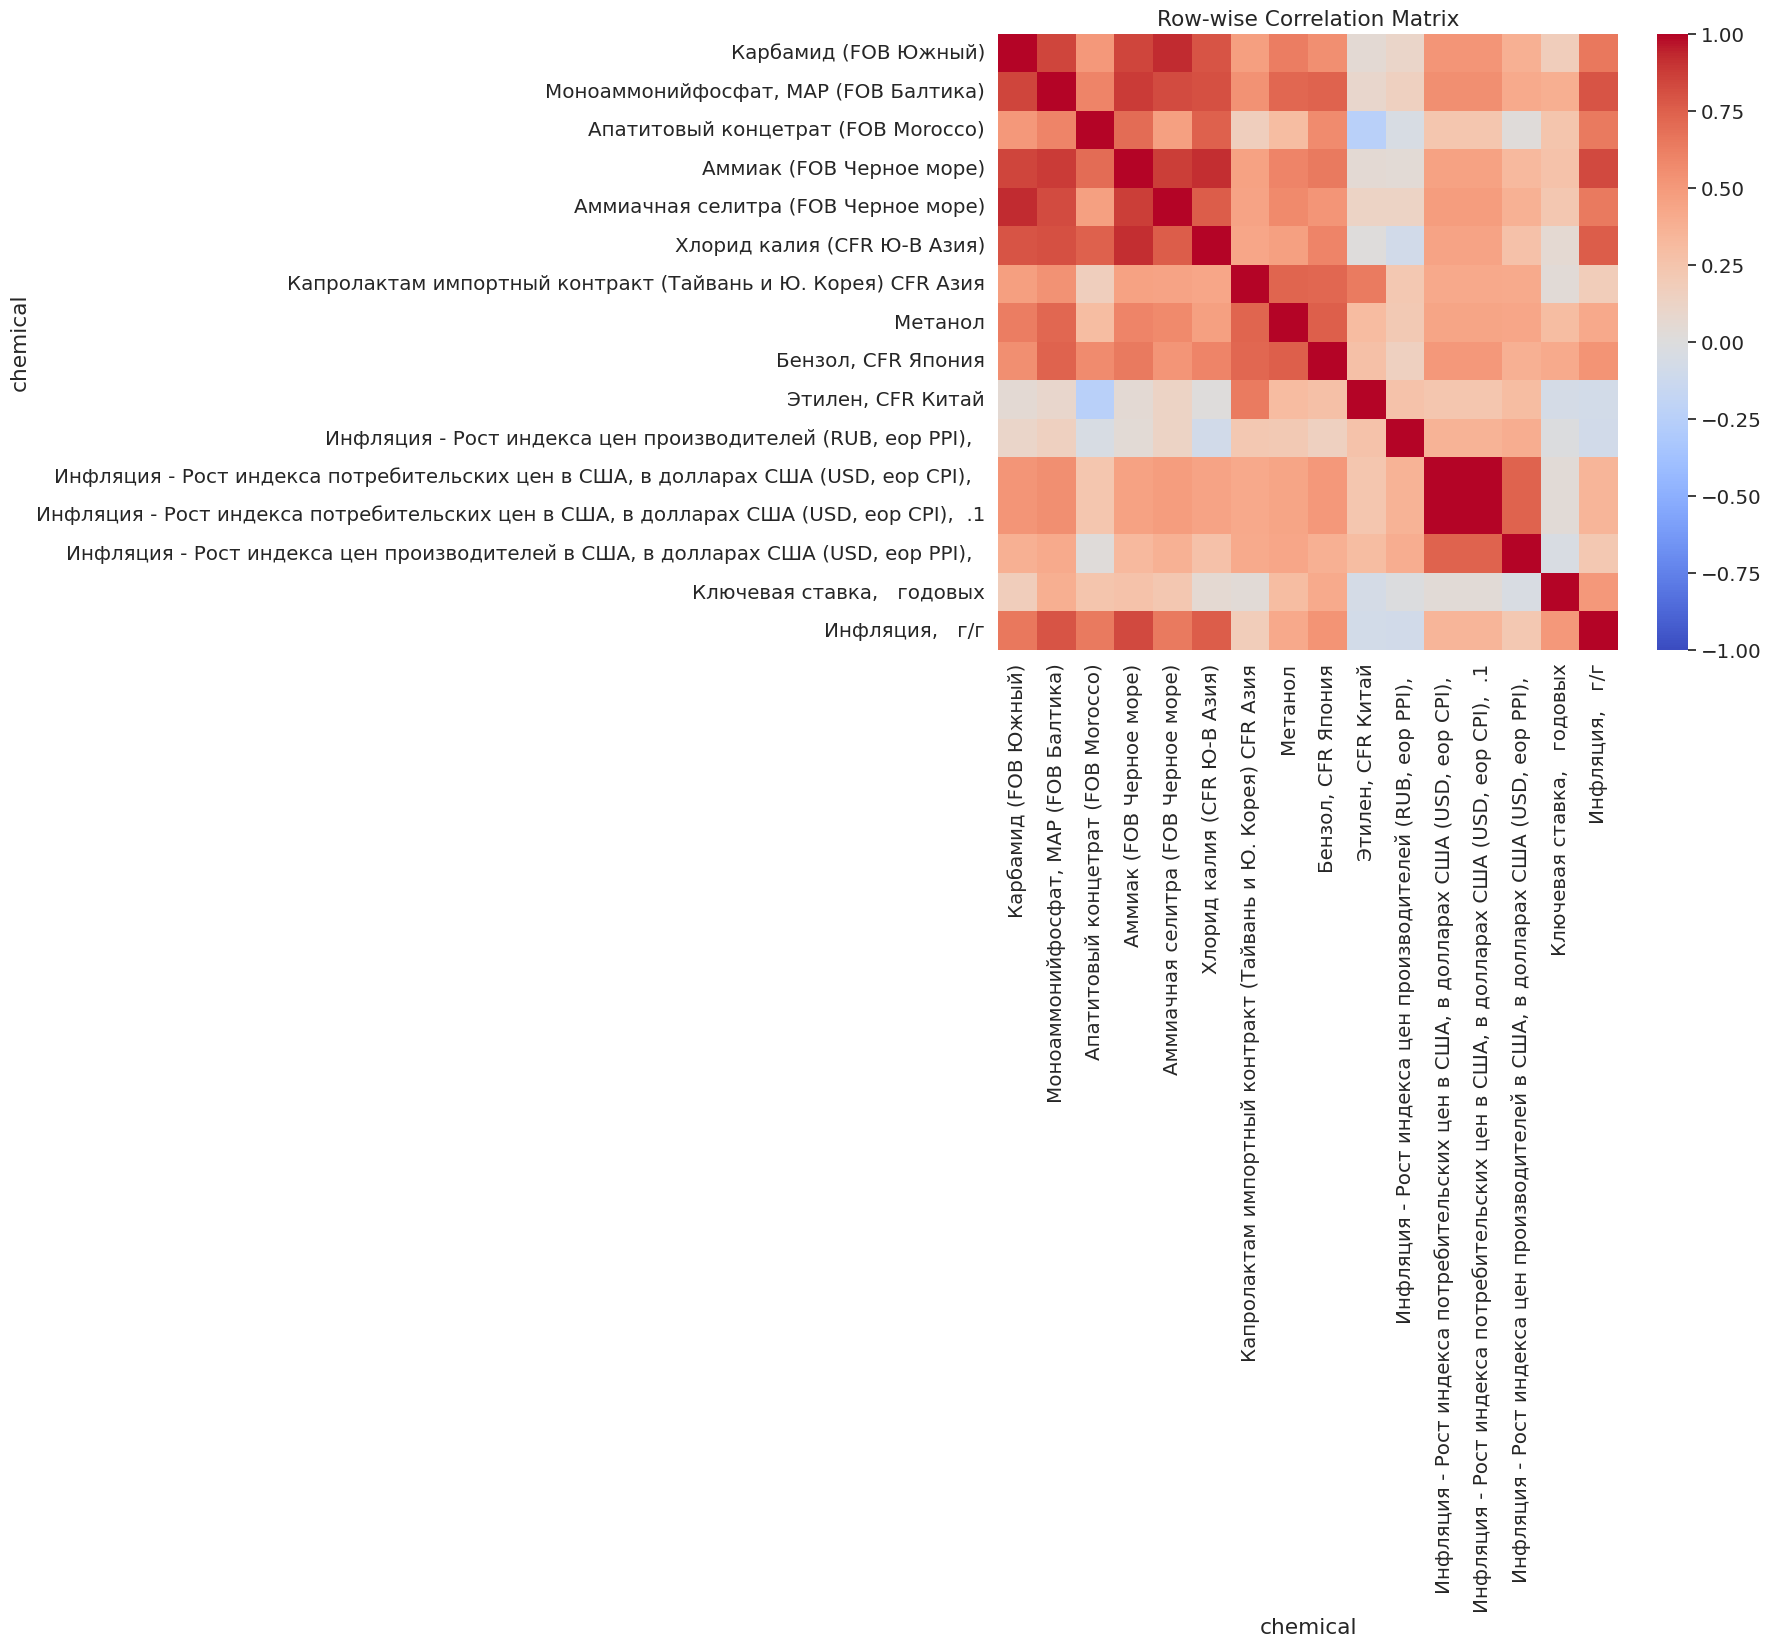

In [10]:
corr_matrix = df_normalized.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Row-wise Correlation Matrix")
plt.show()

## Baseline (single future value)

In [11]:
class SimpleCorrModel:
    def __init__(self, df):
        self.df = df
        self.scaler = StandardScaler()

        self.df_normalized = pd.DataFrame(
            self.scaler.fit_transform(self.df),
            columns=self.df.columns,
            index=self.df.index,
        )

        self.means = self.scaler.mean_
        self.stds = self.scaler.scale_
        self.corr_matrix = self.df_normalized.corr()

    def make_prediction(self, index, value, horizon=12, threshold=0.75):
        # choose columns which have correlation with "index" column greater than threshold
        # return dict
        if index not in self.df.columns:
            raise ValueError(f"Индекс {index} отсутствует в данных")

        norm_value = (
            value - self.scaler.mean_[self.df.columns.get_loc(index)]
        ) / self.scaler.scale_[self.df.columns.get_loc(index)]
        correlations = self.corr_matrix[index]
        correlated = correlations[abs(correlations) >= threshold]

        predictions = {}
        for col, corr in correlated.items():
            # linear approx
            pred_norm = corr * norm_value
            # pred_norm = norm_value

            # denorm
            pred_value = (
                pred_norm * self.scaler.scale_[self.df.columns.get_loc(col)]
                + self.scaler.mean_[self.df.columns.get_loc(col)]
            )
            predictions[col] = pred_value

        return predictions

In [12]:
def cross_validate_corr_model(
    model_class,
    df,
    horizon,
    stride,
    start_window,
    threshold,
    index,
):
    n = len(df)
    errors = {}

    for train_end in range(start_window, n - horizon, stride):
        train_df = df.iloc[:train_end]
        test_start = train_end
        test_end = test_start + horizon
        test_df = df.iloc[test_start:test_end]

        model = model_class(train_df)

        true_target = df[df.columns[index]].iloc[test_start + horizon]
        preds = model.make_prediction(
            index=df.columns[index],
            value=true_target,
            horizon=horizon,
            threshold=threshold,
        )

        for col, pred_value in preds.items():
            true_value = df[col].iloc[test_start + horizon]

            if true_value != 0:
                mape = abs((pred_value - true_value) / true_value) * 100
            else:
                # mape = float("inf") if pred_value != 0 else 0
                mape = min(
                    100, abs((pred_value - true_value) / (true_value + 1e-8)) * 100
                )

            if col not in errors:
                errors[col] = []
            errors[col].append(mape)

    mape_results = {col: f"{np.mean(vals):.1f}%" for col, vals in errors.items()}
    col_count = {col: len(vals) for col, vals in errors.items()}
    return mape_results, col_count

In [13]:
g = SimpleCorrModel(df)

In [14]:
results = cross_validate_corr_model(
    SimpleCorrModel,
    df=df,
    horizon=12,
    stride=1,
    start_window=24,
    threshold=0.9,
    index=-3
)

print(results)

({'Инфляция - Рост индекса цен производителей в США, в долларах США (USD, eop PPI),  ': '0.0%'}, {'Инфляция - Рост индекса цен производителей в США, в долларах США (USD, eop PPI),  ': 78})


In [15]:
def build_error_matrix(
    model_class,
    df,
    horizon,
    stride,
    start_window,
    threshold,
):
    features = df.columns
    error_matrix = pd.DataFrame(index=features, columns=features, dtype=float)

    for i, feat in enumerate(features):
        mape_results, _ = cross_validate_corr_model(
            model_class=model_class,
            df=df,
            horizon=horizon,
            stride=stride,
            start_window=start_window,
            threshold=threshold,
            index=i,
        )

        for col, val in mape_results.items():
            try:
                num_val = float(val.strip("%"))
            except:
                num_val = np.nan
            error_matrix.loc[feat, col] = num_val

    return error_matrix

In [16]:
from matplotlib.colors import Normalize


def plot_error_matrix(
    error_matrix,
    cmap="RdYlGn_r",
    figsize=(10, 8),
    decimals=0,
    vmin=0,
    vmax=100,
    clip=True,
):

    fig, ax = plt.subplots(figsize=figsize)
    data = error_matrix.to_numpy(dtype=float)
    cmap_obj = plt.cm.get_cmap(cmap).copy()
    cmap_obj.set_bad(color="lightgray")

    norm = Normalize(vmin=vmin, vmax=vmax, clip=clip)  # normalize cmap

    im = ax.imshow(data, cmap=cmap_obj, aspect="auto", norm=norm)

    xticklabels = [str(c)[:20] for c in error_matrix.columns]
    yticklabels = [str(r)[:20] for r in error_matrix.index]

    ax.set_xticks(np.arange(len(error_matrix.columns)))
    ax.set_yticks(np.arange(len(error_matrix.index)))
    ax.set_xticklabels(xticklabels, rotation=90)
    ax.set_yticklabels(yticklabels)

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]
            if not np.isnan(val):
                ax.text(
                    j,
                    i,
                    f"{val:.{decimals}f}%",
                    ha="center",
                    va="center",
                    color="black",
                    fontsize=8,
                )

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("MAPE (%)")
    ax.set_xticks(np.arange(-0.5, len(error_matrix.columns), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(error_matrix.index), 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    plt.title(f"Error Matrix (MAPE %) - Colormap anchored to [{vmin}, {vmax}]")
    plt.tight_layout()
    plt.show()

In [17]:
err_mat_12 = build_error_matrix(
    model_class=SimpleCorrModel,
    df=df,
    horizon=12,
    stride=1,
    start_window=24,
    threshold=0.8,
)

/tmp/ipykernel_1045023/1130942838.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = plt.cm.get_cmap(cmap).copy()


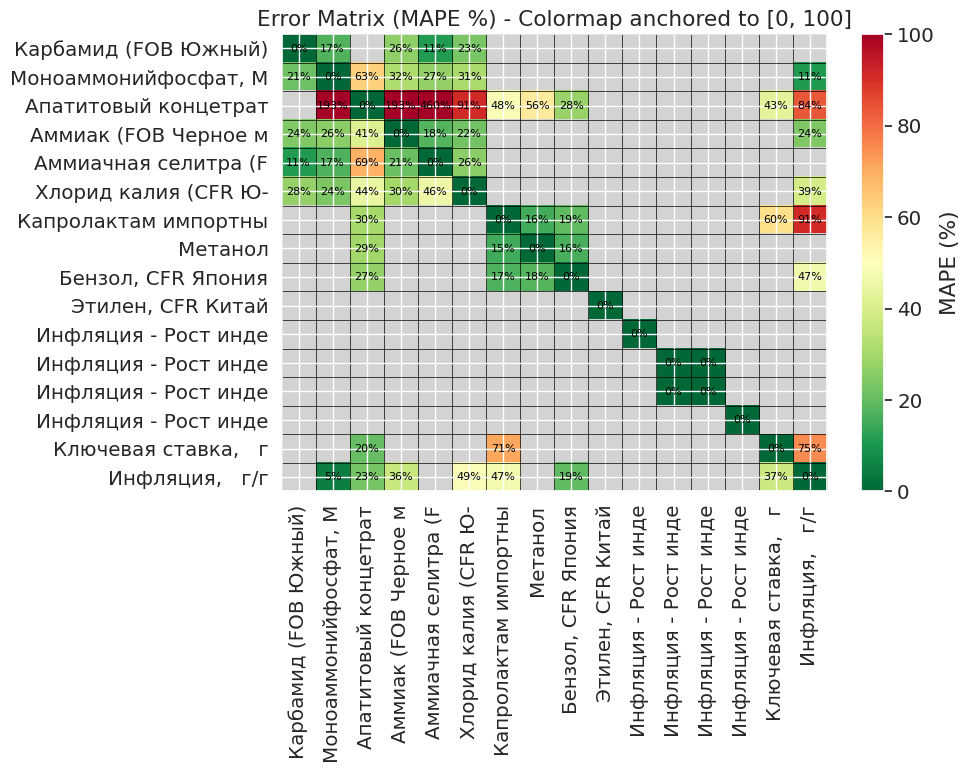

In [18]:
plot_error_matrix(err_mat_12)

### Индивидуальный анализ

In [19]:
window = 60

In [20]:
def plot_series_corr_mape(
    model_class,
    df_normalized,
    df,
    col1,
    col2,
    horizon=12,
    stride=1,
    start_window=24,
    threshold=0.8,
    window=24,
    figsize=(12, 10),
):

    x = df_normalized.index
    y1 = df_normalized[col1].to_numpy()
    y2 = df_normalized[col2].to_numpy()

    cum_corr = [np.corrcoef(y1[:t], y2[:t])[0, 1] for t in range(2, len(x) + 1)]

    roll_corr = pd.Series(y1).rolling(window).corr(pd.Series(y2))

    n = len(df)
    errors, t_stamps = [], []

    for train_end in range(start_window, n - horizon, stride):
        
        train_df = df.iloc[:train_end]
        test_start = train_end
        test_end = test_start + horizon

        model = model_class(train_df)

        true_target = df[col1].iloc[test_start + horizon]
        preds = model.make_prediction(
            index=col1,
            value=true_target,
            horizon=horizon,
            threshold=threshold,
        )

        if col2 in preds:
            t_stamps.append(df.index[train_end])
            pred_value = preds[col2]
            true_value = df[col2].iloc[test_start + horizon]

            if true_value != 0:
                mape = abs((pred_value - true_value) / true_value) * 100
            else:
                mape = min(
                    100, abs((pred_value - true_value) / (true_value + 1e-8)) * 100
                )
            errors.append(mape)

    errors = np.array(errors)
    avg_mape = errors.mean() if len(errors) > 0 else np.nan

    fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=False)

    axes[0].plot(x, y1, label=col1, linewidth=2)
    axes[0].plot(x, y2, label=col2, linewidth=2)
    axes[0].axhline(0, color="black", linestyle="--")
    axes[0].set_title(f"Time Series (normalized): {col1} vs {col2}")
    axes[0].set_ylabel("z-score")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(x[1:], cum_corr, label="Cumulative Corr", color="purple")
    axes[1].plot(x, roll_corr, label=f"Rolling Corr (window={window})", color="orange")
    axes[1].axhline(0, color="black", linestyle="--")
    axes[1].set_title("Correlation Over Time")
    axes[1].set_ylabel("Correlation")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    axes[2].plot(t_stamps, errors, marker="o", color="red", label="MAPE")
    axes[2].axhline(
        avg_mape, color="black", linestyle="--", label=f"Avg = {avg_mape:.1f}%"
    )
    axes[2].set_title(f"MAPE from Cross-Validation ({col1} -> {col2})")
    axes[2].set_xlabel("CV step")
    axes[2].set_ylabel("MAPE (%)")
    axes[2].legend()
    axes[2].grid(alpha=0.3)
    for ax in axes:
        ax.set_xlim(df.index[0], df.index[-1])
    plt.tight_layout()
    plt.show()

In [21]:
model = SimpleCorrModel(df)

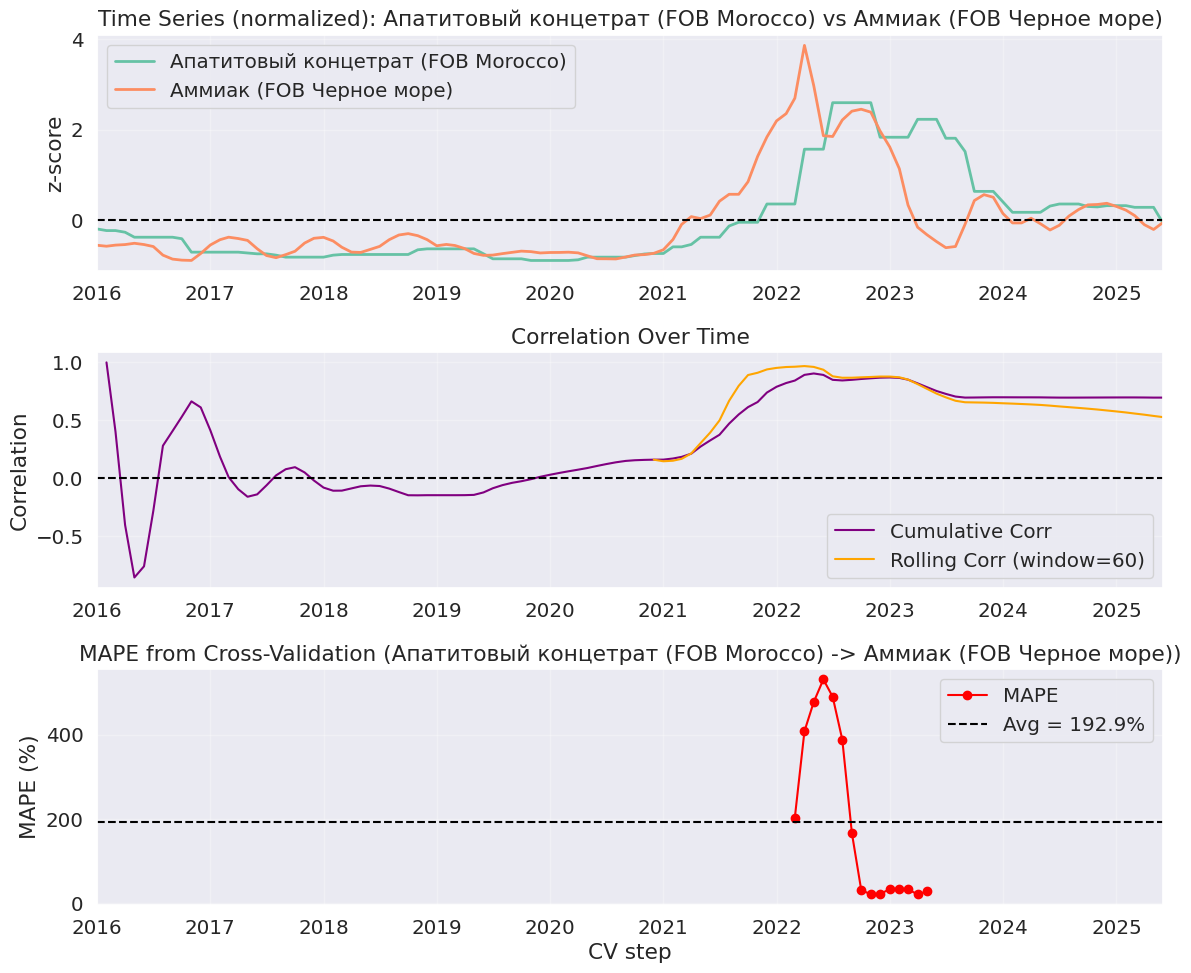

In [22]:
plot_series_corr_mape(
    model_class=SimpleCorrModel,
    df_normalized=model.df_normalized,
    df=model.df,
    col1=df.columns[2],
    col2=df.columns[3],
    horizon=12,
    stride=1,
    start_window=24,
    threshold=0.8,
    window=window,
)

Отсюда сразу напрашивается попробовать скользящую корреляцию вместо глобальной

## Baseline window_corr (single future value)

In [23]:
class SimpleWindowCorrModel:
    def __init__(self, df, window=60):

        self.df = df
        self.window = window
        self.scaler = StandardScaler()

        self.df_normalized = pd.DataFrame(
            self.scaler.fit_transform(self.df),
            columns=self.df.columns,
            index=self.df.index,
        )

        if len(self.df_normalized) >= window:
            self.corr_matrix = self.df_normalized.iloc[-window:].corr()
        else:
            self.corr_matrix = self.df_normalized.corr()

        self.means = self.scaler.mean_
        self.stds = self.scaler.scale_

    def make_prediction(self, index, value, horizon=12, threshold=0.75):

        if index not in self.df.columns:
            raise ValueError(f"Индекс {index} отсутствует в данных")

        norm_value = (
            value - self.scaler.mean_[self.df.columns.get_loc(index)]
        ) / self.scaler.scale_[self.df.columns.get_loc(index)]

        correlations = self.corr_matrix[index]
        correlated = correlations[abs(correlations) >= threshold]

        predictions = {}
        for col, corr in correlated.items():
            pred_norm = corr * norm_value

            pred_value = (
                pred_norm * self.scaler.scale_[self.df.columns.get_loc(col)]
                + self.scaler.mean_[self.df.columns.get_loc(col)]
            )
            predictions[col] = pred_value

        return predictions

In [24]:
err_mat_12 = build_error_matrix(
    model_class=SimpleWindowCorrModel,
    df=df,
    horizon=12,
    stride=1,
    start_window=24,
    threshold=0.8,
)

/tmp/ipykernel_1045023/1130942838.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = plt.cm.get_cmap(cmap).copy()


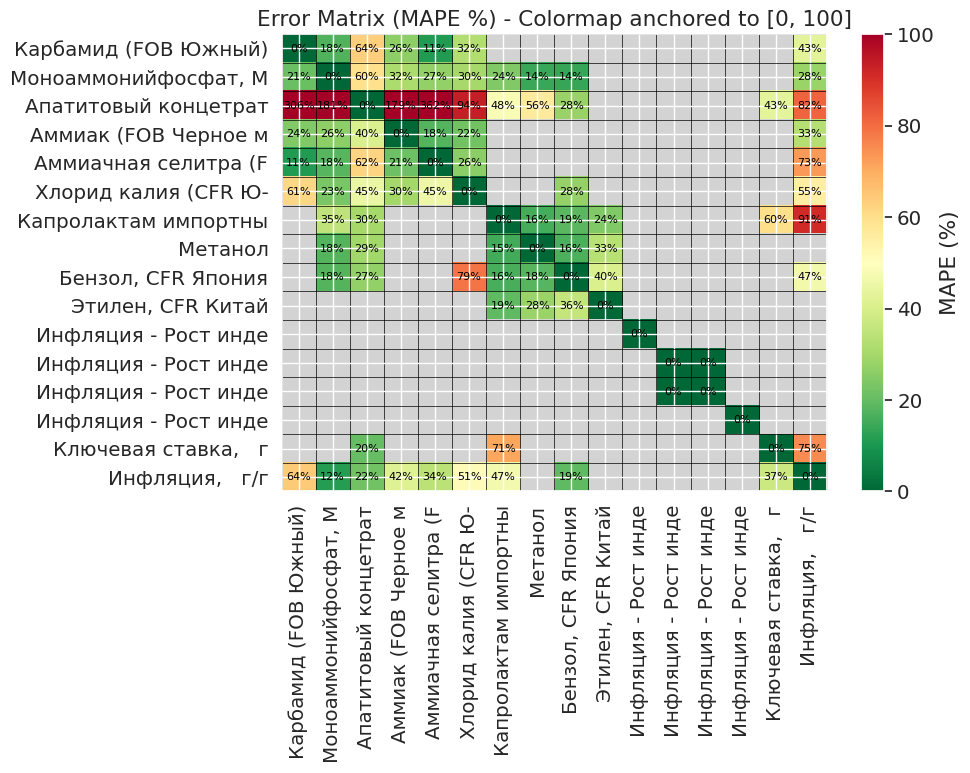

In [25]:
plot_error_matrix(err_mat_12)

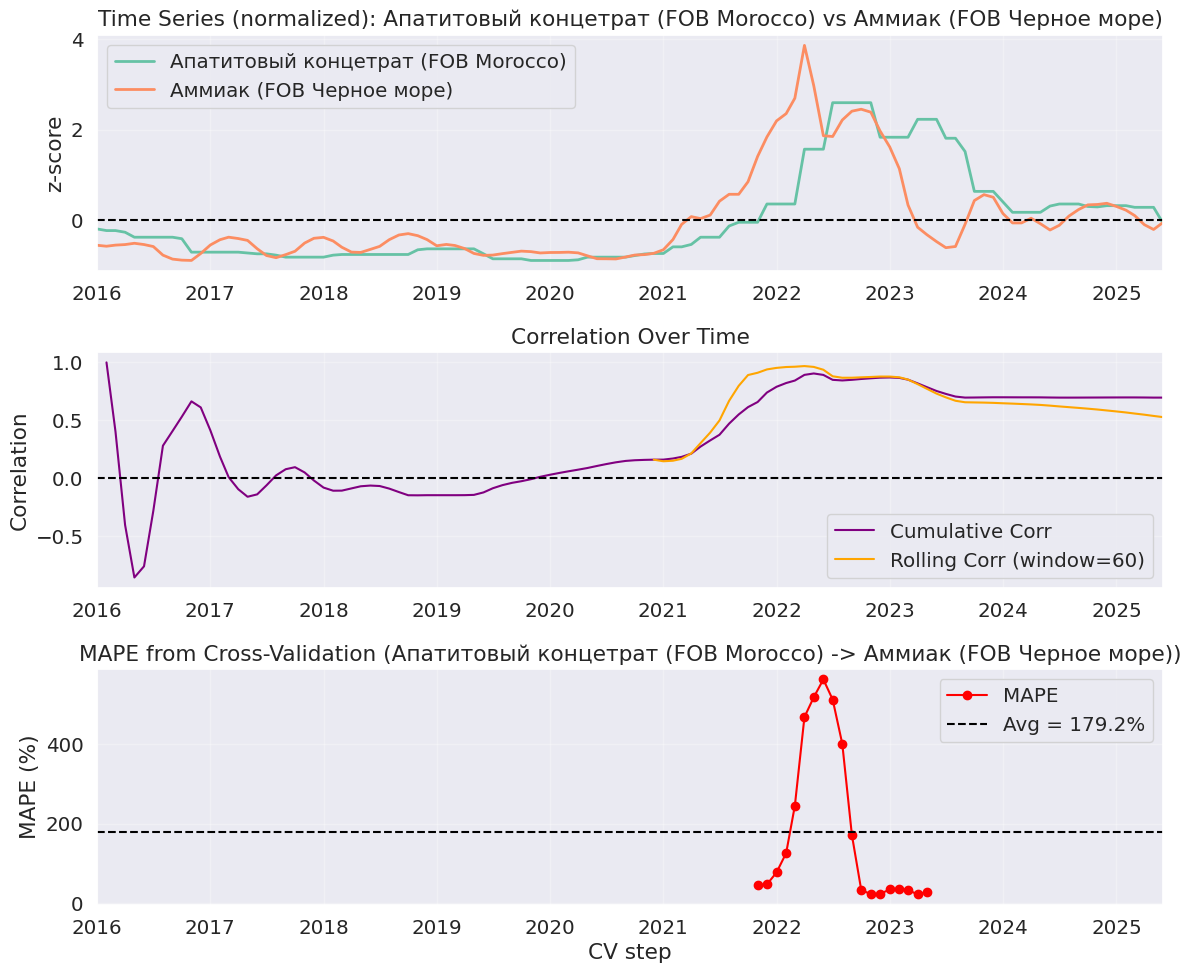

In [26]:
plot_series_corr_mape(
    model_class=SimpleWindowCorrModel,
    df_normalized=SimpleWindowCorrModel(df).df_normalized,
    df=model.df,
    col1=df.columns[2],
    col2=df.columns[3],
    horizon=12,
    stride=1,
    start_window=24,
    threshold=0.8,
    window=window,
)

Видно, что дело в необычности Апатитового концентрата. На своём пике он отклоняется на 4 стандартных отклонения. Также видно

Посмотрим теперь ещё на инфляцию - последний столбец

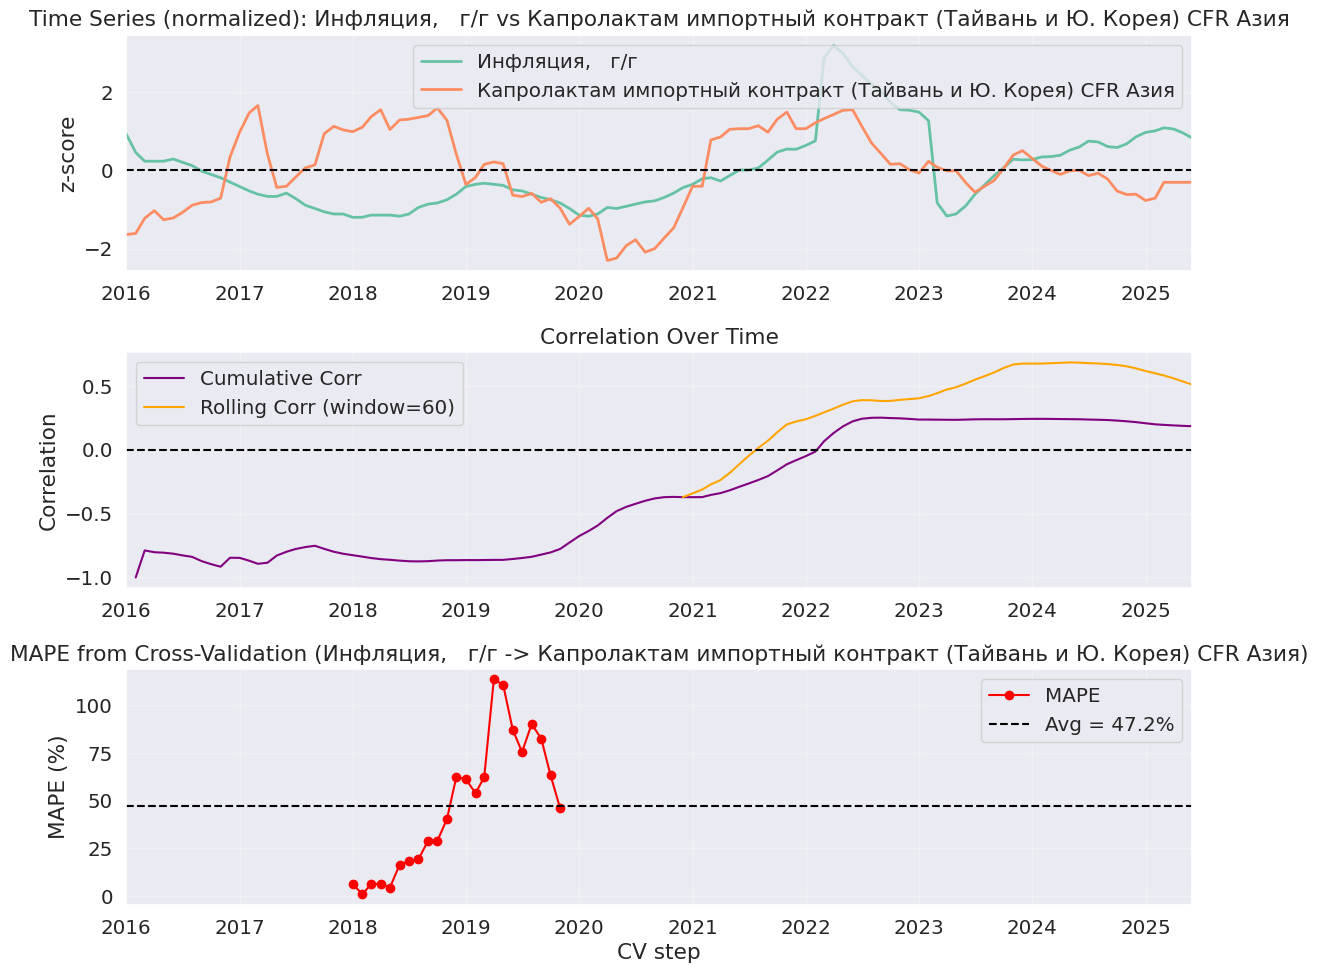

In [27]:
plot_series_corr_mape(
    model_class=SimpleWindowCorrModel,
    df_normalized=SimpleWindowCorrModel(df).df_normalized,
    df=model.df,
    col1=df.columns[-1],
    col2=df.columns[6],
    horizon=12,
    stride=1,
    start_window=24,
    threshold=0.8,
    window=window,
)

In [28]:
df[df.columns[4]]

Date
2016-01-01     199.375
2016-02-01     182.125
2016-03-01       180.3
2016-04-01       172.0
2016-05-01      154.75
                ...   
2025-02-01      274.25
2025-03-01      268.75
2025-04-01      256.25
2025-05-01       262.5
2025-06-01    286.7481
Name: Аммиачная селитра (FOB Черное море), Length: 114, dtype: object

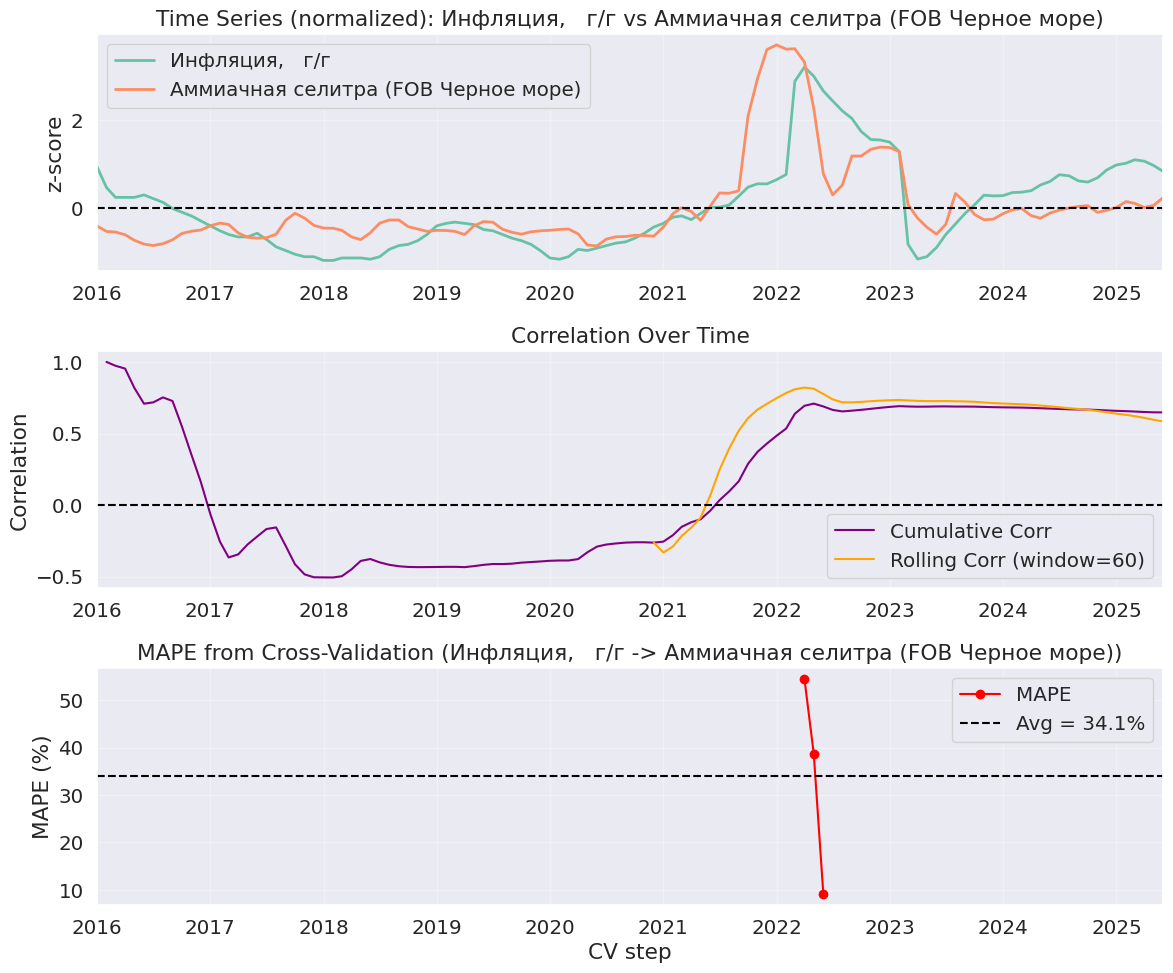

In [29]:
plot_series_corr_mape(
    model_class=SimpleWindowCorrModel,
    df_normalized=SimpleWindowCorrModel(df).df_normalized,
    df=model.df,
    col1=df.columns[-1],
    col2=df.columns[4],
    horizon=12,
    stride=1,
    start_window=24,
    threshold=0.8,
    window=window,
)

## Линейная регрессия 

В случае если мы подаём один показатель на вход, то модель идентична предыдущим. 

In [30]:
class SimpleWindowLinRegModel:
    def __init__(self, df, window=200):

        self.df = df
        self.window = min(window, len(df))
        self.scaler = StandardScaler()

        self.df_normalized = pd.DataFrame(
            self.scaler.fit_transform(self.df),
            columns=self.df.columns,
            index=self.df.index,
        )

        self.means = self.scaler.mean_
        self.stds = self.scaler.scale_

    def make_prediction(self, indices, values, threshold):
        df_window = self.df_normalized.iloc[-self.window :]
        X = df_window[indices].values
        preds = {}

        norm_values = []
        for col, val in zip(indices, values):
            mean = self.scaler.mean_[self.df.columns.get_loc(col)]
            std = self.scaler.scale_[self.df.columns.get_loc(col)]
            norm_values.append((val - mean) / std)
        norm_values = np.array(norm_values).reshape(1, -1)

        for target_col in self.df.columns:
            y = df_window[target_col].values
            model = LinearRegression()
            model.fit(X, y)
            y_pred_train = model.predict(X)
            mse = mean_squared_error(y, y_pred_train)

            if mse < threshold:
                y_pred_future = model.predict(norm_values)[0]
                mean = self.scaler.mean_[self.df.columns.get_loc(target_col)]
                std = self.scaler.scale_[self.df.columns.get_loc(target_col)]
                y_pred_future_denorm = y_pred_future * std + mean
                preds[target_col] = y_pred_future_denorm

        return preds

In [31]:
model = SimpleWindowLinRegModel(df, window=window)
preds = model.make_prediction(
    indices=[df.columns[1], df.columns[2]],
    values=[200, 500],
    threshold=2,
)
print(preds)


{'Карбамид (FOB Южный)': 124.92575545474196, 'Моноаммонийфосфат, MAP (FOB Балтика)': 200.0, 'Апатитовый концетрат (FOB Morocco)': 500.0, 'Аммиак (FOB Черное море)': 510.56640392426067, 'Аммиачная селитра (FOB Черное море)': 36.82538812834923, 'Хлорид калия (CFR Ю-В Азия)': 604.2688464484747, 'Капролактам импортный контракт (Тайвань и Ю. Корея) CFR Азия': 1248.9830656351758, 'Метанол': 154.31108696578437, 'Бензол, CFR Япония': 894.7488395515054, 'Этилен, CFR Китай': 482.8859400660849, 'Инфляция - Рост индекса цен производителей (RUB, eop PPI),  ': -0.026045536486493475, 'Инфляция - Рост индекса потребительских цен в США, в долларах США (USD, eop CPI),  ': -0.2809507844764189, 'Инфляция - Рост индекса потребительских цен в США, в долларах США (USD, eop CPI),  .1': -0.2809507844764189, 'Инфляция - Рост индекса цен производителей в США, в долларах США (USD, eop PPI),  ': -0.009514904672172099, 'Ключевая ставка,   годовых': 6.413921552846979, 'Инфляция,   г/г': 5.955216847491337}


Работает. Не знаю как считать метрики